# TAWOS Issue Dataset Analysis

This notebook explores the full TAWOS `Issue` table loaded from MySQL. It summarizes missing fields, story point distribution, class imbalance, priority breakdown, and description length — supporting investigation of training data quality for effort estimation.

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

REPO_ROOT = Path("..").resolve()
sys.path.insert(0, str(REPO_ROOT))

from scripts.tawos_data import (
    compute_summary,
    load_issues,
    project_summary,
    story_point_counts,
    story_point_counts_by_project,
    top_projects_by_labeled_tickets,
)

sns.set_theme(style="whitegrid")

df = load_issues()
summary = compute_summary(df)
df.head()


,Story_Point,Title,Description,Description_Text,Priority
0,1.0,"""How do I make a job restartable in spring xd""","""The jobs that appear under Executions section...","""""""The jobs that appear under Executions secti...",Major
1,1.0,"""admin config timezone command does not work""","""Working with Spring-XD version 1.3.2.RELEASE ...","""""""Working with Spring-XD version 1.3.2.RELEAS...",Trivial
2,10.0,"""Module Upload command not pushing jar to all ...","""My project 7 node cluster and in that 2 node ...","""""""My project 7 node cluster and in that 2 nod...",Major
3,8.0,"""Fix stream failover ""","""See https://github.com/spring-projects/spring...","""""""See https://github.com/spring-projects/spri...",Minor
4,5.0,"""SpringXD Job is still executing even after fo...","""I'm trying to run a Job on SpringXD and the j...","""""""I'm trying to run a Job on SpringXD and the...",Major


## Dataset overview

The Issue table contains software tickets with story points, titles, descriptions, and priority labels. The row count below is the full dataset size used for downstream analysis.

In [2]:
print(f"Total tickets: {summary['total']:,}")
print(f"Unique story point values: {summary['unique_story_points']:,}")

Total tickets: 458,232
Unique story point values: 367


## Missing-field summary

Tickets missing key fields may be unsuitable for supervised training. The table below shows absolute counts and percentages for each field.

In [3]:
missing_summary = pd.DataFrame(
    {
        "metric": [
            "Missing Story_Point",
            "Missing Title",
            "Missing Description_Text",
            "Missing Priority",
        ],
        "count": [
            summary["missing_story_point"],
            summary["missing_title"],
            summary["missing_description"],
            summary["missing_priority"],
        ],
    }
)
missing_summary["pct"] = (
    missing_summary["count"] / summary["total"] * 100
).round(1)

missing_summary


,metric,count,pct
0,Missing Story_Point,392805,85.7
1,Missing Title,0,0.0
2,Missing Description,29128,6.4
3,Missing Priority,124073,27.1


## Story point distribution

Story points are the target label for effort estimation. This chart shows how many tickets fall into each story point value, including missing labels.

In [4]:
sp_counts = story_point_counts(df)
sp_counts

,story_point,count,story_point_label
0,NaN,392805,Missing
1,0.000000e+00,2416,0
2,1.000000e-04,1,0.0001
3,1.000000e-02,1,0.01
4,2.000000e-02,3,0.02
...,...,...,...
363,1.000000e+03,1,1000
364,2.567000e+03,1,2567
365,3.030000e+03,1,3030
366,6.765000e+03,1,6765


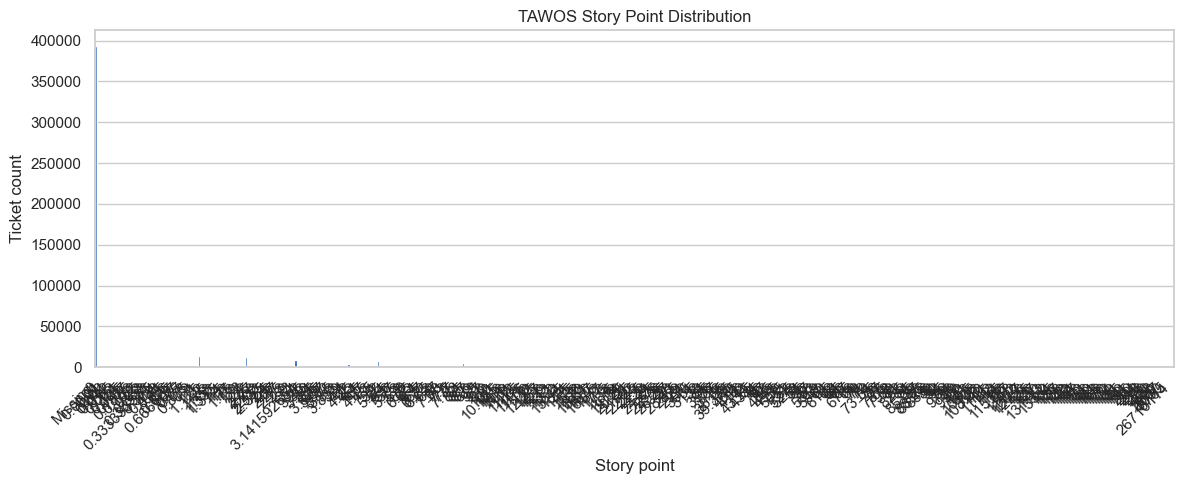

In [5]:
plt.figure(figsize=(12, 5))
sns.barplot(data=sp_counts, x="story_point_label", y="count", color="#0052CC")
plt.title("TAWOS Story Point Distribution")
plt.xlabel("Story point")
plt.ylabel("Ticket count")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

## Class imbalance

Highly skewed story point distributions can bias a classifier toward common values. The percentage view makes imbalance easier to compare across classes.

In [6]:
sp_pct = sp_counts.copy()
sp_pct["pct"] = (sp_pct["count"] / summary["total"] * 100).round(2)
sp_pct[["story_point_label", "count", "pct"]]

,story_point_label,count,pct
0,Missing,392805,85.72
1,0,2416,0.53
2,0.0001,1,0.00
3,0.01,1,0.00
4,0.02,3,0.00
...,...,...,...
363,1000,1,0.00
364,2567,1,0.00
365,3030,1,0.00
366,6765,1,0.00


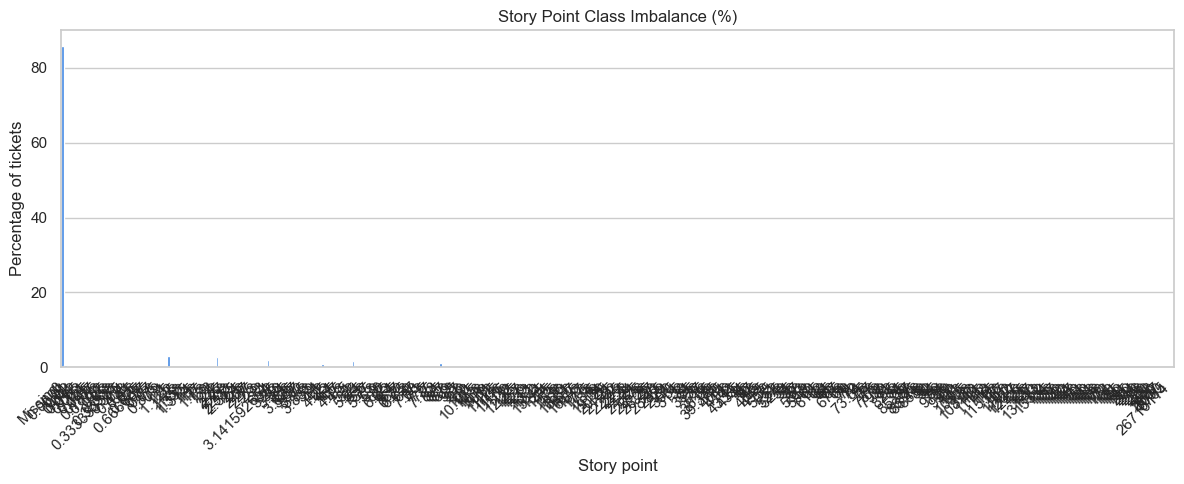

In [7]:
plt.figure(figsize=(12, 5))
sns.barplot(data=sp_pct, x="story_point_label", y="pct", color="#2684FF")
plt.title("Story Point Class Imbalance (%)")
plt.xlabel("Story point")
plt.ylabel("Percentage of tickets")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

## Per-project story point breakdown

TAWOS mixes several distinct open-source projects. Global story-point imbalance may look different when broken down by project. The table below ranks projects by ticket count; charts show rounded story-point distribution for the top projects by labeled ticket count.

In [ ]:
projects = project_summary(df)
projects

In [ ]:
plt.figure(figsize=(10, max(4, len(projects) * 0.35)))
sns.barplot(
    data=projects,
    y="Project_Name",
    x="total_tickets",
    color="#0052CC",
)
plt.title("Tickets per project")
plt.xlabel("Ticket count")
plt.ylabel("Project")
plt.tight_layout()
plt.show()

In [ ]:
top_projects = top_projects_by_labeled_tickets(df, n=5)
top_projects

In [ ]:
fig, axes = plt.subplots(len(top_projects), 1, figsize=(12, 4 * len(top_projects)))
if len(top_projects) == 1:
    axes = [axes]

for ax, project_name in zip(axes, top_projects):
    sp_by_project = story_point_counts_by_project(df, project_name)
    sns.barplot(
        data=sp_by_project,
        x="story_point_label",
        y="count",
        color="#2684FF",
        ax=ax,
    )
    ax.set_title(f"Rounded story points — {project_name}")
    ax.set_xlabel("Story point (rounded)")
    ax.set_ylabel("Ticket count")
    ax.tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

## Rounded story points (cleaned view)

Some tickets have fractional story point values (for example `2.567` or `3.03`). For a cleaner training-label view, the charts below apply standard rounding to whole numbers (`2.567 → 3`, `3.03 → 3`) at display time only. The loaded `df` and the raw charts above are unchanged.

In [8]:
from scripts.tawos_data import fractional_story_point_stats, rounded_story_point_counts

frac_stats = fractional_story_point_stats(df)
cleaning_summary = pd.DataFrame(
    {
        "metric": [
            "Tickets with fractional Story_Point",
            "Unique story point values (raw)",
            "Unique story point values (rounded)",
        ],
        "count": [
            frac_stats["fractional_story_points"],
            frac_stats["unique_raw"],
            frac_stats["unique_rounded"],
        ],
    }
)
cleaning_summary

,metric,count
0,Tickets with fractional Story_Point,3337
1,Unique story point values (raw),367
2,Unique story point values (rounded),164


In [9]:
sp_rounded_counts = rounded_story_point_counts(df)
sp_rounded_counts

,story_point,count,story_point_label
0,NaN,392805,Missing
1,0.0,4617,0
2,1.0,14401,1
3,2.0,12293,2
4,3.0,9010,3
...,...,...,...
160,1000.0,1,1000
161,2567.0,1,2567
162,3030.0,1,3030
163,6765.0,1,6765


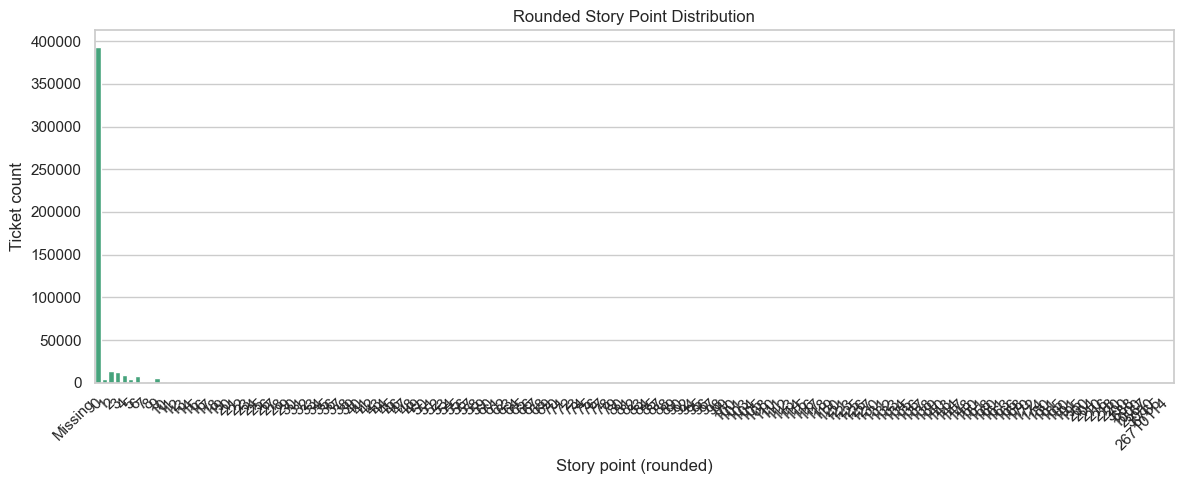

In [10]:
plt.figure(figsize=(12, 5))
sns.barplot(data=sp_rounded_counts, x="story_point_label", y="count", color="#36B37E")
plt.title("Rounded Story Point Distribution")
plt.xlabel("Story point (rounded)")
plt.ylabel("Ticket count")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

## Priority breakdown

Priority labels provide additional context about ticket urgency. This section shows how priority values are distributed across the dataset.

In [11]:
priority_counts = (
    df["Priority"]
    .value_counts(dropna=False)
    .reset_index(name="count")
)
priority_counts.columns = ["priority", "count"]
priority_counts["priority"] = priority_counts["priority"].fillna("Missing")
priority_counts

,priority,count
0,,124073
1,Low,65819
2,Major - P3,57146
3,Medium,56920
4,Minor,55819
5,Major,34212
6,High,24447
7,Critical,11341
8,Trivial,6617
9,Minor - P4,5947


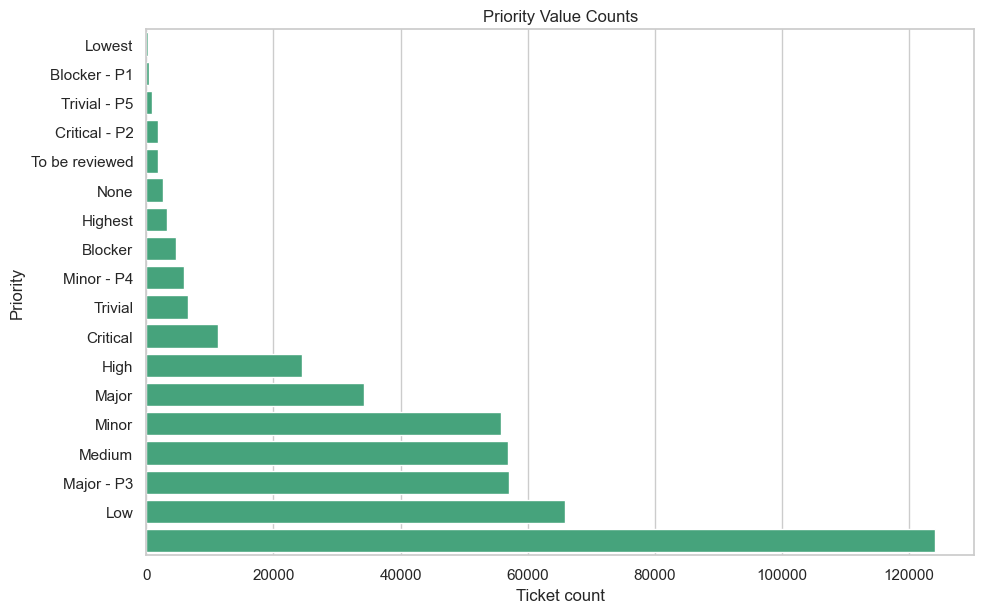

In [12]:
plt.figure(figsize=(10, max(4, len(priority_counts) * 0.35)))
sns.barplot(
    data=priority_counts.sort_values("count"),
    y="priority",
    x="count",
    color="#36B37E",
)
plt.title("Priority Value Counts")
plt.xlabel("Ticket count")
plt.ylabel("Priority")
plt.tight_layout()
plt.show()

## Description length

Longer descriptions may give models more signal for estimation. The summary statistics and histogram below describe the character length of `Description_Text`.

In [13]:
desc_lengths = df["Description_Text"].str.len()
desc_lengths.describe().to_frame("characters")

,characters
count,4.582320e+05
mean,6.185192e+02
std,3.358296e+03
min,0.000000e+00
25%,1.850000e+02
50%,3.790000e+02
75%,6.620000e+02
max,1.391310e+06


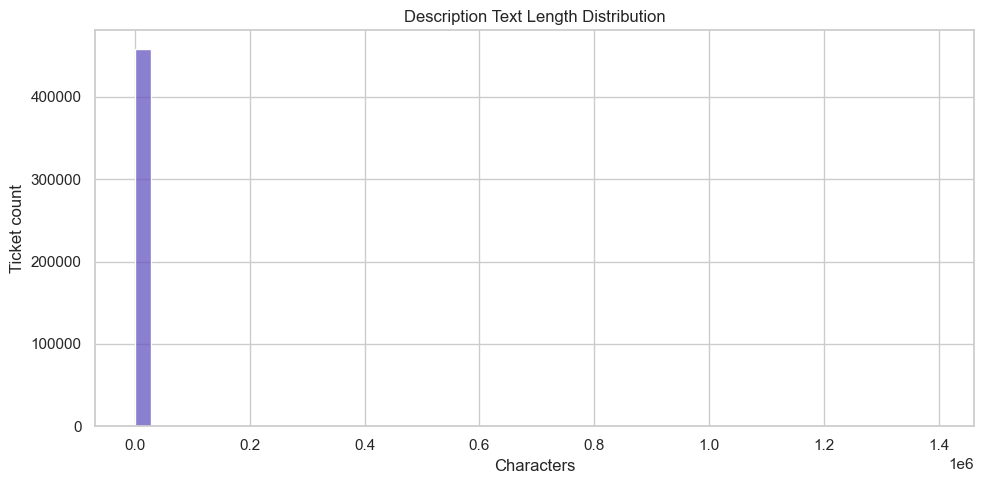

In [14]:
plt.figure(figsize=(10, 5))
sns.histplot(desc_lengths.dropna(), bins=50, color="#6554C0")
plt.title("Description Text Length Distribution")
plt.xlabel("Characters")
plt.ylabel("Ticket count")
plt.tight_layout()
plt.show()